In [ ]:
## Este archivo analiza la tolerancia de los codigos seleccionados para el movimiento de la implementación biomórfica.

## Se hara: Modelo, verificador visual, corrimiento de tolerancia y figuras.


In [5]:
#Instancias de librerias
## Import Libraries
import numpy as np
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D
import time
import csv
import os

%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from scipy import signal

import pandas as pd

In [6]:
#****************************************************************************************
#Modelo de neuronas de Rulkov no caóticas
#****************************************************************************************

In [21]:
## RULKOVINE
## Developed on Arduino MEGA 2560 and UNO
#We declare method three neurons based on Rulkov Map modeling:

class RulkovMapV4:
    """
    Creates a Rulkov Map model to apply three neuron coupling. Using diferent alpha values but equal sigma and g values.
    UPDATE V4: Use a simplified Rulkov Map Neuron. Using the same value for sigmas, initial values x and y, and conductance g values. Use fixed betae value to 0.113
    """
    def __init__(self, alpha1=6, alpha2=6, alpha3=6, mu=0.001, sigma=0.3, g=0):
        """
        Initializes the model.

        Args:
            alpha1 (int, float): Non-Lineal variable alpha for neuron 1
            alpha2 (int, float): Non-Lineal Variable alpha for neuron 2
            alpha3 (int, float): Non-Lineal Variable alpha for neuron 3
            mu (int, float): Variable mu. Control of evolution of y, slow dynamic control.
            sigmas (int float): Initial value for sigma1, 2 and 3. Inter neural activation current.
            initialxy (int, float): Initial value for the membrane potential in neuron 1, 2 and 3. Initial value for the slow dynamics in neuron 1, 2 and 3.
            g (int, float): values for: gij Conductance between Neuron i and j.  Conductance between neurons terminals

            METHODS:

            *run: create temporal series for three neurons which have Ext. Currents created by Potential difference between Neuronal Membrane in axons
            *


        """
        #Inicialization
        self.alpha1 = alpha1
        self.alpha2 = alpha2
        self.alpha3 = alpha3
        self.mu = mu
        self.sigma1 = sigma
        self.sigma2 = sigma
        self.sigma3 = sigma
        self.betae = None
        self.sigmae = None
        self.g12 = g
        self.g21 = g
        self.g31 = g
        self.g13 = g
        self.g23 = g
        self.g32 = g
        self.x10 = None
        self.y10 = None
        self.x20 = None
        self.y20 = None
        self.x30 = None
        self.y30 = None
        self.beta12n = None
        self.beta13n = None
        self.beta21n = None
        self.beta23n = None
        self.beta31n = None
        self.beta32n = None
        self.sigma12n = None
        self.sigma13n = None
        self.sigma21n = None
        self.sigma23n = None
        self.sigma31n = None
        self.sigma32n = None
        self.t = None
        self.tevol = None
        self.status = " "
        self.cuad1=[]
        self.cuad2=[]
        self.cuad3=[]
        self.sum_cuad = []

    def __repr__(self):
        """
        Visualize model parameters when printing.
        """
        return f'RulkovModel(alpha1={self.alpha1}, alpha2={self.alpha2}, alpha3={self.alpha3}, mu={self.mu}, sigma1={self.sigma1}, sigma2={self.sigma2},sigma3={self.sigma3}, x10={self.x10}, y10= {self.y10},x20={self.x20}, y20= {self.y20},x30={self.x30}, y30= {self.y30}, g12={self.g12}, g13={self.g13}, g21={self.g21}, g23={self.g23}, g31={self.g31},g32={self.g32} betae={self.betae}, sigmae={self.sigmae}), cuad1={self.cuad1}, cuad2={self.cuad2}, cuad3={self.cuad3}, sum_cuad={self.sum_cuad}'

    def run(self, t=1000):
        """
        Run the model by iterating the system. Neuron i variables could be identified as xi, yi, ect.
        Args:

            t (int, optional): Total time for the simulation. Defaults to 1000.
            

        """
        self.t = t
        self.beta12n0=0
        self.beta13n0=0
        self.beta21n0=0
        self.beta23n0=0
        self.beta31n0=0
        self.beta32n0=0
        self.x10 = 0
        self.y10 = 0
        self.x20 = 0
        self.y20 = 0
        self.x30 = 0
        self.y30 = 0
        self.betae = 0.113 #fixed Value. Same as Tristan et. al (2014)
        self.sigmae = 1

        self.tevol = np.arange(0, self.t)
        #Neuron 1
        self.x1 = np.zeros(self.tevol.shape)
        self.y1 = np.zeros(self.tevol.shape)
        self.beta12n = np.zeros(self.tevol.shape)
        self.beta13n = np.zeros(self.tevol.shape)
        self.sigma12n = np.zeros(self.tevol.shape)
        self.sigma13n = np.zeros(self.tevol.shape)

        #Neuron 2
        self.x2 = np.zeros(self.tevol.shape)
        self.y2 = np.zeros(self.tevol.shape)
        self.beta21n = np.zeros(self.tevol.shape)
        self.beta23n = np.zeros(self.tevol.shape)
        self.sigma21n = np.zeros(self.tevol.shape)
        self.sigma23n = np.zeros(self.tevol.shape)

        #Neuron 3
        self.x3 = np.zeros(self.tevol.shape)
        self.y3 = np.zeros(self.tevol.shape)
        self.beta31n = np.zeros(self.tevol.shape)
        self.beta32n = np.zeros(self.tevol.shape)
        self.sigma31n = np.zeros(self.tevol.shape)
        self.sigma32n = np.zeros(self.tevol.shape)


        #Initianizing signals
        self.x1[-1] = self.x10
        self.y1[-1] = self.y10
        self.x2[-1] = self.x20
        self.y2[-1] = self.y20
        self.x3[-1] = self.x30
        self.y3[-1] = self.y30
        self.beta12n[-1]=self.beta12n0
        self.beta13n[-1]=self.beta13n0
        self.beta21n[-1]=self.beta21n0
        self.beta23n[-1]=self.beta23n0
        self.beta31n[-1]=self.beta31n0
        self.beta32n[-1]=self.beta32n0

        for t in self.tevol:
          #generacion de X1
            if self.x1[t - 1] <= 0:
                self.x1[t] = (self.alpha1 / (1 - self.x1[t - 1])) + self.y1[t - 1]+self.beta12n[t-1]+self.beta13n[t-1]

            elif ((0 < self.x1[t - 1] < self.alpha1 + self.y1[t - 1]+ self.beta12n[t-1]+self.beta13n[t-1])and(self.x1[t - 2]<= 0)):
                self.x1[t] = self.alpha1 + self.y1[t - 1]+self.beta12n[t-1]+self.beta13n[t-1]



            elif ((self.x1[t - 1] >= (self.alpha1 + self.y1[t - 1]+self.beta12n[t-1]+self.beta13n[t-1]))or(self.x1[t - 2] > 0)):
                self.x1[t] = -1

          #generacion de X2
            if self.x2[t - 1] <= 0:
                self.x2[t] = (self.alpha2 / (1 - self.x2[t - 1])) + self.y2[t - 1]+self.beta21n[t-1]+self.beta23n[t-1]

            elif ((0 < self.x2[t - 1] < self.alpha2 + self.y2[t - 1]+ self.beta21n[t-1]+ self.beta23n[t-1])and(self.x2[t - 2]<= 0)):
                self.x2[t] = self.alpha2 + self.y2[t - 1]+self.beta21n[t-1]+self.beta23n[t-1]
                self.x2[t] = self.alpha2 + self.y2[t - 1]+self.beta21n[t-1]+self.beta23n[t-1]


            elif ((self.x2[t - 1] >= (self.alpha2 + self.y2[t - 1]+self.beta21n[t-1]+self.beta23n[t-1]))or (self.x2[t - 2] >0)):
                self.x2[t] = -1

            #Generación de X3
            if self.x3[t - 1] <= 0:
                self.x3[t] = (self.alpha3 / (1 - self.x3[t - 1])) + self.y3[t - 1]+self.beta31n[t-1] +self.beta32n[t-1]

            elif ((0 < self.x3[t - 1] < self.alpha3 + self.y3[t - 1]+ self.beta31n[t-1]+self.beta32n[t-1])and(self.x3[t - 2]<= 0)):
                self.x3[t] = self.alpha3 + self.y3[t - 1]+self.beta31n[t-1]+self.beta32n[t-1]


            elif ((self.x3[t - 1] >= (self.alpha3 + self.y3[t - 1]+self.beta31n[t-1]+self.beta32n[t-1]))or (self.x3[t - 2] >0)):
                self.x3[t] = -1

            #for neuron 1
            self.beta12n[t] = (self.g12*self.betae)*(self.x2[t]-self.x1[t])
            self.sigma12n[t] = (self.g12*self.sigmae)*(self.x2[t]-self.x1[t])
            self.beta13n[t] = (self.g13*self.betae)*(self.x3[t]-self.x1[t])
            self.sigma13n[t] = (self.g13*self.sigmae)*(self.x3[t]-self.x1[t])

            #for neuron 2
            self.beta21n[t] = (self.g12*self.betae)*(self.x1[t]-self.x2[t])
            self.sigma21n[t] = (self.g12*self.sigmae)*(self.x1[t]-self.x2[t])
            self.beta23n[t] = (self.g23*self.betae)*(self.x3[t]-self.x2[t])
            self.sigma23n[t] = (self.g23*self.sigmae)*(self.x3[t]-self.x2[t])

            #for neuron 2
            self.beta31n[t] = (self.g13*self.betae)*(self.x1[t]-self.x3[t])
            self.sigma31n[t] = (self.g13*self.sigmae)*(self.x1[t]-self.x3[t])
            self.beta32n[t] = (self.g23*self.betae)*(self.x2[t]-self.x3[t])
            self.sigma32n[t] = (self.g23*self.sigmae)*(self.x2[t]-self.x3[t])

            self.y1[t] = self.y1[t - 1] - (self.mu * (self.x1[t - 1] + 1)) + (self.mu*(self.sigma1 + self.sigma12n[t - 1] + self.sigma13n[t - 1]))
            #self.y1[t] = self.y1[t - 1] - (self.mu * (self.x1[t - 1] + 1)) + (self.mu*(self.sigma1 + self.sigma12n[t - 1]))
            self.y2[t] = self.y2[t - 1] - (self.mu * (self.x2[t - 1] + 1)) + (self.mu*(self.sigma2 + self.sigma21n[t - 1] + self.sigma23n[t - 1]))
            #self.y2[t] = self.y2[t - 1] - (self.mu * (self.x2[t - 1] + 1)) + (self.mu*(self.sigma2  + self.sigma23n[t - 1]))
            self.y3[t] = self.y3[t - 1] - (self.mu * (self.x3[t - 1] + 1)) + (self.mu*(self.sigma3 + self.sigma31n[t - 1] + self.sigma32n[t - 1]))
            #self.y3[t] = self.y3[t - 1] - (self.mu * (self.x3[t - 1] + 1)) + (self.mu*(self.sigma3 + self.sigma31n[t - 1] ))


#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
#Function normalization_v2:
#Receive x1, x2, x3 from run.
#Return Signals x1,x2,x3 normalizated
    def normalization_v2 (self):
        #*********************************
        #NEURON crop from 3000 to 10000 ms
        #*********************************
        #Neuron 1
        my_signal1 = self.x1
        signal1 = my_signal1[-7000:]
        #Neuron 2
        my_signal2 = self.x2
        signal2 = my_signal2[-7000:]
        #Neuron 3
        my_signal3 = self.x3
        signal3 = my_signal3[-7000:]
        #***********************************************************
        #Signal x1 Normalization: send all values between 0 and 1
        #***********************************************************
        s1_norm = (signal1 - np.min(signal1)) / (np.max(signal1) - np.min(signal1))
        # Bursting detection signal x1
        umbral_superior1 = 0.8  # Superior edge (must be, at least, 0.9)
        umbral_inferior1 = 0.1  # Inferior edge (very sensitive parameter. Must be equal to each signal. Fixed between 0.10 to 0.15)
        # Inicialization of starage buffers
        inicio_burstings1 = []
        fin_burstings1 = []
        # Bursting detection
        en_bursting1 = False  # Search variable for burst
        for i in range(len(s1_norm)):
            if s1_norm[i] > umbral_superior1 and not en_bursting1:
                inicio_burstings1.append(i)
                en_bursting1 = True
            elif s1_norm[i] < umbral_inferior1 and en_bursting1:
                fin_burstings1.append(i)
                en_bursting1 = False
        #Create a new square serie: 1 in bursting, 0 other values.
            serie_cuadrada1 = np.zeros(len(signal1))
        for inicio, fin in zip(inicio_burstings1, fin_burstings1):
            serie_cuadrada1[inicio:fin] = 1

        self.cuad1 = serie_cuadrada1

        #***********************************************************
        #Signal x2 Normalization: send all values between 0 and 1
        #***********************************************************
        s2_norm = (signal2 - np.min(signal2)) / (np.max(signal2) - np.min(signal2))

        # Bursting detection signal x2
        umbral_superior2 = 0.8  # Superior edge (must be, at least, 0.9)
        umbral_inferior2 = 0.1  # Inferior edge (very sensitive parameter. Must be equal to each signal. Fixed between 0.10 to 0.15)
        # Inicialization of starage buffers
        inicio_burstings2 = []
        fin_burstings2 = []
        # Bursting detection
        en_bursting2 = False  # Search variable for burst
        for i in range(len(s2_norm)):
            if s2_norm[i] > umbral_superior2 and not en_bursting2:
                inicio_burstings2.append(i)
                en_bursting2 = True
            elif s2_norm[i] < umbral_inferior2 and en_bursting2:
                fin_burstings2.append(i)
                en_bursting2 = False

        #Create a new square serie: 1 in bursting, 0 other values.
        serie_cuadrada2 = np.zeros(len(signal2))
        for inicio, fin in zip(inicio_burstings2, fin_burstings2):
            serie_cuadrada2[inicio:fin] = 1

        self.cuad2 = serie_cuadrada2

        #***********************************************************
        #Signal x3 Normalization: send all values between 0 and 1
        #***********************************************************
        s3_norm = (signal3 - np.min(signal3)) / (np.max(signal3) - np.min(signal3))

        # Bursting detection signal x3
        umbral_superior3 = 0.8  # Superior edge (must be, at least, 0.9)
        umbral_inferior3 = 0.1  # # Inferior edge (very sensitive parameter. Must be equal to each signal. Fixed between 0.10 to 0.15)

        # Inicialization of storage buffers
        inicio_burstings3 = []
        fin_burstings3 = []
        # Bursting detection
        en_bursting3 = False  # Search variable for burst
        for i in range(len(s3_norm)):
            if s3_norm[i] > umbral_superior3 and not en_bursting3:
                inicio_burstings3.append(i)
                en_bursting3 = True
            elif s3_norm[i] < umbral_inferior3 and en_bursting3:
                fin_burstings3.append(i)
                en_bursting3 = False

       #Create a new square serie: 1 in bursting, 0 other values.
        serie_cuadrada3 = np.zeros(len(signal3))
        for inicio, fin in zip(inicio_burstings3, fin_burstings3):
            serie_cuadrada3[inicio:fin] = 1

        self.cuad3 = serie_cuadrada3

        self.sum_cuad = (self.cuad1 + self.cuad2 +self.cuad3)
        

#%%%%%%%%%%%%%%%%%%%%%%
#Function grafic_X: 
#Generate a X (mV) vs t (ms) graphic. Usually, RulkovINO uses 10k steps of iteration (each step=1ms). First 3000 steps are ignored because are part of stabilization pediod.

    def grafic_X (self):
      fig,ax = plt.subplots(4,1,figsize=(6,4))
      ax[0].plot(self.x1[-7000:-4000],color='b')
      ax[1].plot(self.x2[-7000:-4000],color='r')
      ax[2].plot(self.x3[-7000:-4000],color='g')
      ax[3].plot((self.x1[-7000:-4000]+self.x2[-7000:-4000]+self.x3[-7000:-4000]), color='grey')
      #ax[0].legend()
      #ax[1].legend()
      #ax[2].legend()
      #ax[3].legend()
      ax[3].set_xlabel("n")
      ax[0].set_ylabel("$x^1_n$")
      ax[1].set_ylabel("$x^2_n$")
      ax[2].set_ylabel("$x^3_n$")
      ax[3].set_ylabel("$x^{sum}_n$")
      plt.tight_layout()

      plt.show()    
        
#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
#Function graf_normalization:
#Receive x1, x2, x3 normalizated and graph them

    def graf_normalization(self):
        
      fig,ax = plt.subplots(4,1,figsize=(6,4))
      ax[0].plot(self.cuad1[-7000:-4000],color='b')
      ax[1].plot(self.cuad2[-7000:-4000],color='r')
      ax[2].plot(self.cuad3[-7000:-4000],color='g')
      ax[3].plot(self.sum_cuad[-7000:-4000], color='grey')
      #ax[0].legend()
      #ax[1].legend()
      #ax[2].legend()
      #ax[3].legend()
      ax[3].set_xlabel("n")
      ax[0].set_ylabel(r"$\hat{x^1_n}$")
      ax[1].set_ylabel(r"$\hat{x^2_n}$")
      ax[2].set_ylabel(r"$\hat{x^3_n}$")
      ax[3].set_ylabel(r"$\hat{x^{sum}_n}$")
      plt.tight_layout()

      plt.show()

#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
#Function silence_ver:
#Receive x1, x2, x3 normalizated and graph them
    def silence_ver(self):
      """
      Silence signal verificator. If a signal is complete zero,
      Return 1. If has at least 1 non-zero value, return 0.
      """
      allZero=0
      init=0
      fin= len(self.sum_cuad)
      
      for i in range(init,fin): #search zero in the last 6000 values of signal
        if (self.sum_cuad[i] > 0): #si el valor es diferente de cero,
            allZero=+1            #stat aumenta desde cero

      if (allZero==0): #If allZero never change, always zero in signal.
        return 1
      else:         #If allZero is diff of 0, means is not in silence status
        return 0
#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
#Function WLC Verificator:


    def ver_WLC_V1(self):
        change = 0  # Contador de cambios
        WLC = -4    # Estado inicial de la bandera
        rang0 = []  # Índices donde la señal es <= 1
        init = 1000  # Índice inicial #1000
        fin = len(self.sum_cuad)   # Índice final

        # Bandera para verificar si todos los valores son cero
        all_zero = True  

        # Iterar sobre el rango definido
        for i in range(init, fin):
            if self.sum_cuad[i] > 1:  # Si dos o más señales están activas
                change += 1
                all_zero = False  # Al menos un valor no es cero
            elif self.sum_cuad[i] > 0:  # Si la señal está entre 0 y 1
                all_zero = False  # Al menos un valor no es cero
                rang0.append(i)
            else:  # Si la señal es exactamente 0
                rang0.append(i)

            # Si todos los valores son cero, registrar un cambio
        if all_zero:
            change += 1

        # Determinar el estado de WLC
        if change == 0:
            WLC = 1  # No hubo cambios
        else:
            WLC = 0  # Hubo cambios

        return WLC


    

In [22]:
#***************************************
#graficador manual
#*****************************************


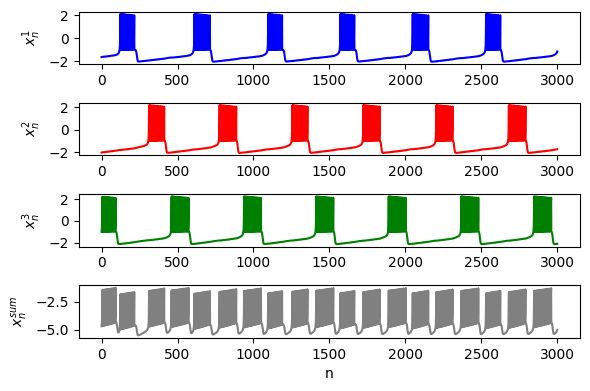

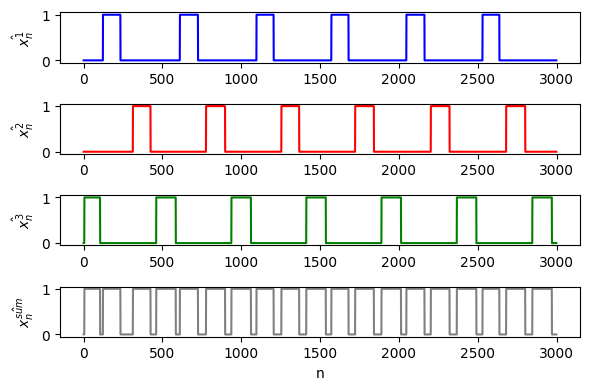

*************************************************
Se confirma que para estos valores, hay WLC
*************************************************


In [23]:
#valores de Tristan g=-0.09 sigma 0.06

#N3= RulkovMapV4(alpha1=6.5, alpha2=6.6, alpha3=6.7, mu=0.001, sigma=-0.5, g=-0.02) #code 0
N3= RulkovMapV4(alpha1=6.0, alpha2=6.1, alpha3=6.2, mu=0.001, sigma=-0.4, g=-0.03) #code 1
#N3= RulkovMapV4(alpha1=5.2, alpha2=5.3, alpha3=5.4, mu=0.001, sigma=-0.2, g=-0.04) #code 2
#N3= RulkovMapV4(alpha1=4.0, alpha2=4.1, alpha3=4.2, mu=0.001, sigma=0, g=0.06) #code 3


N3.run(10000)
N3.grafic_X()
N3.normalization_v2()
N3.graf_normalization()
N3.silence_ver()
Z=N3.ver_WLC_V1()

print("*************************************************")
if (Z == 1):
 print("Se confirma que para estos valores, hay WLC")
else:
 print("No hay WLC")
print("*************************************************")

In [24]:
#analisis y funciones nuevas

In [25]:
def evaluate_wlc_point(alpha1, sigma, g, dalpha=0.10, t=10000):
    """
    Evalúa si un punto mantiene la dinámica WLC.
    """

    model = RulkovMapV4(
        alpha1=alpha1,
        alpha2=alpha1 + dalpha,
        alpha3=alpha1 + 2*dalpha,
        mu=0.001,
        sigma=sigma,
        g=g
    )

    model.run(t=t)
    model.normalization_v2()

    silencio = model.silence_ver()
    wlc = model.ver_WLC_V1()

    if wlc == 1 and silencio == 0:
        result = 1
    else:
        result = 0

    return result

In [26]:
def find_limit_one_parameter(
    param_name,
    base_params,
    step,
    max_steps=200,
    direction=1,
    dalpha=0.10,
    t=10000
):
    """
    Busca el límite de WLC variando un solo parámetro.
    
    direction = +1 hacia adelante
    direction = -1 hacia atrás
    """

    current_params = base_params.copy()

    last_valid_value = current_params[param_name]
    first_invalid_value = None

    for k in range(1, max_steps + 1):

        test_value = base_params[param_name] + direction * k * step
        current_params[param_name] = test_value

        p = evaluate_wlc_point(
            alpha1=current_params["alpha1"],
            sigma=current_params["sigma"],
            g=current_params["g"],
            dalpha=dalpha,
            t=t
        )

        if p == 1:
            last_valid_value = test_value
        else:
            first_invalid_value = test_value
            break

    return {
        "parameter": param_name,
        "direction": direction,
        "base_value": base_params[param_name],
        "last_valid_value": last_valid_value,
        "first_invalid_value": first_invalid_value,
        "steps_checked": k
    }

In [27]:
def tolerance_limits_for_code(
    code_name,
    alpha1_base,
    sigma_base,
    g_base,
    step_alpha=0.01,
    step_sigma=0.01,
    step_g=0.001,
    max_steps=200,
    dalpha=0.10,
    t=10000
):
    """
    Calcula tolerancias hacia adelante y atrás
    variando un parámetro a la vez.
    """

    base_params = {
        "alpha1": alpha1_base,
        "sigma": sigma_base,
        "g": g_base
    }

    steps = {
        "alpha1": step_alpha,
        "sigma": step_sigma,
        "g": step_g
    }

    results = []

    for param_name in ["alpha1", "sigma", "g"]:
        for direction in [-1, 1]:

            result = find_limit_one_parameter(
                param_name=param_name,
                base_params=base_params,
                step=steps[param_name],
                max_steps=max_steps,
                direction=direction,
                dalpha=dalpha,
                t=t
            )

            result["code"] = code_name
            results.append(result)

    return pd.DataFrame(results)

In [28]:
def summarize_tolerance_limits(df_limits):
    summary = []

    for param in df_limits["parameter"].unique():

        dfp = df_limits[df_limits["parameter"] == param]

        lower = dfp[dfp["direction"] == -1]["last_valid_value"].values[0]
        upper = dfp[dfp["direction"] == 1]["last_valid_value"].values[0]
        base = dfp["base_value"].values[0]

        summary.append({
            "parameter": param,
            "base_value": base,
            "lower_valid_limit": lower,
            "upper_valid_limit": upper,
            "negative_tolerance": base - lower,
            "positive_tolerance": upper - base,
            "total_valid_width": upper - lower
        })

    return pd.DataFrame(summary)

In [39]:
# ======================================
# RESOLUCIÓN PARAMÉTRICA DEL HARDWARE
# ======================================

alpha_step_hw = 0.1
sigma_step_hw = 1/1023
g_step_hw = 0.2/1023

print("Alpha step =", alpha_step_hw)
print("Sigma step =", sigma_step_hw)
print("g step =", g_step_hw)

Alpha step = 0.1
Sigma step = 0.0009775171065493646
g step = 0.00019550342130987292


In [29]:
#Code 0: alfa=6.5 sigma=-0.5 g=-0.02
evaluate_wlc_point(
    alpha1=6.5,
    sigma=-0.50,
    g=-0.02
)

1

In [38]:
df_limits_code0_hw = tolerance_limits_for_code(
    code_name="Code_0_HW",
    alpha1_base=6.5,
    sigma_base=-0.50,
    g_base=-0.02,
    step_alpha=0.1,
    step_sigma=1/1023,
    step_g=0.2/1023,
    max_steps=100,
    t=10000
)

df_limits_code0_hw

,parameter,direction,base_value,last_valid_value,first_invalid_value,steps_checked,code
0,alpha1,-1,6.50,6.500000,6.400000,1,Code_0_HW
1,alpha1,1,6.50,6.500000,6.600000,1,Code_0_HW
2,sigma,-1,-0.50,-0.500000,-0.500978,1,Code_0_HW
3,sigma,1,-0.50,-0.499022,-0.498045,2,Code_0_HW
4,g,-1,-0.02,-0.020978,-0.021173,6,Code_0_HW
5,g,1,-0.02,-0.019413,-0.019218,4,Code_0_HW


In [40]:
def hardware_tolerance_summary(df):
    
    rows = []

    for param in df["parameter"].unique():

        sub = df[df["parameter"] == param]

        lower = sub[sub["direction"] == -1]["last_valid_value"].values[0]
        upper = sub[sub["direction"] == 1]["last_valid_value"].values[0]
        base  = sub["base_value"].values[0]

        rows.append({
            "parameter": param,
            "base_value": base,
            "lower_limit": lower,
            "upper_limit": upper,
            "width": upper - lower,
            "negative_tol": base - lower,
            "positive_tol": upper - base
        })

    return pd.DataFrame(rows)

In [42]:
print("For code 0:")
summary_hw = hardware_tolerance_summary(df_limits_code0_hw)

summary_hw

For code 0:


,parameter,base_value,lower_limit,upper_limit,width,negative_tol,positive_tol
0,alpha1,6.50,6.500000,6.500000,0.000000,0.000000,0.000000
1,sigma,-0.50,-0.500000,-0.499022,0.000978,0.000000,0.000978
2,g,-0.02,-0.020978,-0.019413,0.001564,0.000978,0.000587


In [43]:
def paper_line(df):

    txt = []

    for _, row in df.iterrows():

        txt.append(
            f"{row['parameter']} = "
            f"[{row['lower_limit']:.6f}, "
            f"{row['upper_limit']:.6f}]"
        )

    return "; ".join(txt)

In [45]:
paper_line(summary_hw)

'alpha1 = [6.500000, 6.500000]; sigma = [-0.500000, -0.499022]; g = [-0.020978, -0.019413]'

In [46]:
#**********************************
#RESUMEN
#***********************************

In [47]:
# ==========================================================
# HARDWARE ROBUSTNESS ANALYSIS FOR THE FOUR SYMBOLIC CODES
# ==========================================================

# Resolución física del Arduino
alpha_step_hw = 0.1
sigma_step_hw = 1/1023
g_step_hw = 0.2/1023

hardware_steps = {
    "alpha1": alpha_step_hw,
    "sigma": sigma_step_hw,
    "g": g_step_hw
}

In [49]:
#N3= RulkovMapV4(alpha1=6.5, alpha2=6.6, alpha3=6.7, mu=0.001, sigma=-0.5, g=-0.02) #code 0
#N3= RulkovMapV4(alpha1=6.0, alpha2=6.1, alpha3=6.2, mu=0.001, sigma=-0.4, g=-0.03) #code 1
#N3= RulkovMapV4(alpha1=5.2, alpha2=5.3, alpha3=5.4, mu=0.001, sigma=-0.2, g=-0.04) #code 2
#N3= RulkovMapV4(alpha1=4.0, alpha2=4.1, alpha3=4.2, mu=0.001, sigma=0, g=0.06) #code 3
codes = {
    "Code_0": {"alpha1": 6.5, "sigma": -0.50, "g": -0.02},
    "Code_1": {"alpha1": 6.0, "sigma": -0.40, "g": -0.03},
    "Code_2": {"alpha1": 5.2, "sigma": -0.20, "g": -0.04},
    "Code_3": {"alpha1": 4.0, "sigma": 0.00, "g": 0.06},
}

In [50]:
def hardware_stable_steps_for_code(
    code_name,
    alpha1_base,
    sigma_base,
    g_base,
    max_steps=100,
    t=10000
):
    df_limits = tolerance_limits_for_code(
        code_name=code_name,
        alpha1_base=alpha1_base,
        sigma_base=sigma_base,
        g_base=g_base,
        step_alpha=alpha_step_hw,
        step_sigma=sigma_step_hw,
        step_g=g_step_hw,
        max_steps=max_steps,
        t=t
    )

    rows = []

    for param in ["alpha1", "sigma", "g"]:

        sub = df_limits[df_limits["parameter"] == param]

        neg = sub[sub["direction"] == -1].iloc[0]
        pos = sub[sub["direction"] == 1].iloc[0]

        rows.append({
            "parameter": param,
            "code": code_name,
            "base_value": neg["base_value"],
            "negative_stable_steps": neg["steps_checked"] - 1,
            "positive_stable_steps": pos["steps_checked"] - 1,
            "lower_valid_limit": neg["last_valid_value"],
            "upper_valid_limit": pos["last_valid_value"]
        })

    return pd.DataFrame(rows), df_limits

In [57]:
all_summary = []
all_limits = {}

for code_name, params in codes.items():

    print(f"Running {code_name}...")

    summary_code, limits_code = hardware_stable_steps_for_code(
        code_name=code_name,
        alpha1_base=params["alpha1"],
        sigma_base=params["sigma"],
        g_base=params["g"],
        max_steps=100,
        t=10000
    )

    all_summary.append(summary_code)
    all_limits[code_name] = limits_code

df_all_summary = pd.concat(all_summary, ignore_index=True)

df_all_summary

Running Code_0...
Running Code_1...
Running Code_2...
Running Code_3...


,parameter,code,base_value,negative_stable_steps,positive_stable_steps,lower_valid_limit,upper_valid_limit
0,alpha1,Code_0,6.50,0,0,6.500000,6.500000
1,sigma,Code_0,-0.50,0,1,-0.500000,-0.499022
2,g,Code_0,-0.02,5,3,-0.020978,-0.019413
3,alpha1,Code_1,6.00,3,0,5.700000,6.000000
4,sigma,Code_1,-0.40,4,2,-0.403910,-0.398045
5,g,Code_1,-0.03,8,7,-0.031564,-0.028631
6,alpha1,Code_2,5.20,5,1,4.700000,5.300000
7,sigma,Code_2,-0.20,99,5,-0.297752,-0.195112
8,g,Code_2,-0.04,68,52,-0.053294,-0.029834
9,alpha1,Code_3,4.00,0,0,4.000000,4.000000


In [59]:
table_steps = df_all_summary.pivot(
    index="parameter",
    columns="code",
    values=["negative_stable_steps", "positive_stable_steps"]
)

table_steps

negative_stable_steps                      positive_stable_steps  \
code                     Code_0 Code_1 Code_2 Code_3                Code_0   
parameter                                                                    
alpha1                        0      3      5      0                     0   
g                             5      8     68     46                     3   
sigma                         0      4     99     22                     1   

                                
code      Code_1 Code_2 Code_3  
parameter                       
alpha1         0      1      0  
g              7     52     53  
sigma          2      5      8